## 1. Load Data from Yahoo Finance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install yfinance -qq
import yfinance as yf

from xgboost import XGBRegressor
!pip install --upgrade pip -qq
!pip install lightgbm -qq
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

ERROR: To modify pip, please run the following command:
C:\Users\oadsa\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip -qq


In [17]:
# Choose asset (you can change this)
ticker = "ETH-USD"   # Bitcoin: BTC-USD, Apple: AAPL

# Download data
df = yf.download(ticker, start="2020-01-01", end="2025-01-01")

# Fix yfinance Multi-index structure and convert to a standard clean DataFrame
df.columns = df.columns.get_level_values(0)

# Extract 'Close' explicitly as a 1D Series to prevent multi-dimensional matrix bugs
close_series = df['Close'].squeeze()
df = df.reset_index()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2020-01-01,130.802002,132.835358,129.198288,129.630661,7935230330
1,2020-01-02,127.410179,130.820038,126.954910,130.820038,8032709256
2,2020-01-03,134.171707,134.554016,126.490021,127.411263,10476845358
3,2020-01-04,135.069366,136.052719,133.040558,134.168518,7430904515
4,2020-01-05,136.276779,139.410202,135.045624,135.072098,7526675353


## 2. Feature Engineering (Lag + Rolling)

In [24]:
# 1. Feature engineering
df['return'] = df['Close'].pct_change()
df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df['lag_7'] = df['Close'].shift(7)
df['rolling_mean_7'] = df['Close'].rolling(7).mean()
df['rolling_std_7'] = df['Close'].rolling(7).std()
df['momentum_7'] = df['lag_1'] - df['lag_7']


## 3. Detrending

In [25]:
df['trend'] = df['Close'].rolling(window=20).mean()
df['detrended'] = df['Close'] - df['trend']

df = df.dropna().reset_index(drop=True)

## 4. Define Features & Target

In [26]:
features = [
    'lag_1', 'lag_2', 'lag_7',
    'rolling_mean_7', 'rolling_std_7',
    'momentum_7'
]

X = df[features]
y = df['detrended']

## 5. Train-Test Split (No leakage)

In [27]:
train_size = int(len(df) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

## 6. Train XGBoost

In [28]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# .values.ravel() converts the pandas DataFrame column into a clean, flat 1D array
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

## 7. Train LightGBM

In [29]:
lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 1431, number of used features: 6
[LightGBM] [Info] Start training from score 13.921121


## 8. Reconstruct Final Prediction

In [30]:
trend_test = df['trend'].iloc[train_size:].values

final_xgb = xgb_pred + trend_test
final_lgbm = lgbm_pred + trend_test

actual = df['Close'].iloc[train_size:].values

## 9. Evaluation

In [31]:
xgb_rmse = np.sqrt(mean_squared_error(actual, final_xgb))
lgbm_rmse = np.sqrt(mean_squared_error(actual, final_lgbm))

print("XGBoost RMSE:", xgb_rmse)
print("LightGBM RMSE:", lgbm_rmse)

XGBoost RMSE: 195.46520522212396
LightGBM RMSE: 201.32160472863723


In [34]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_scores.append(rmse)

print("Average RMSE:", np.mean(rmse_scores))

Average RMSE: 200.423338597032


## 10. Feature Importance

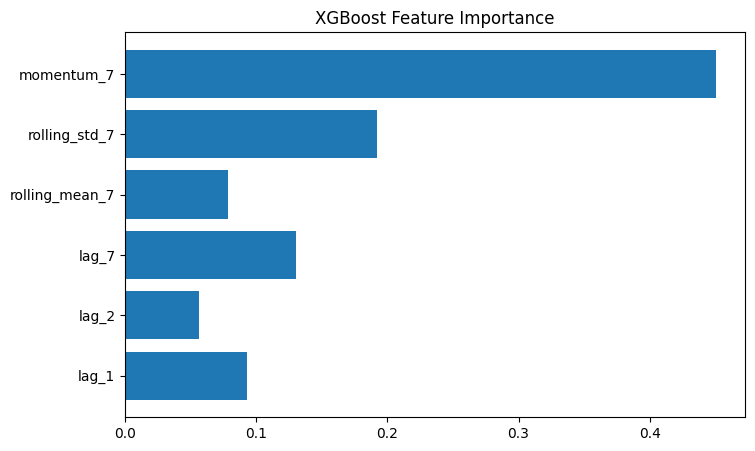

In [32]:
importance = xgb_model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("XGBoost Feature Importance")
plt.show()

## 11. Final Visualization

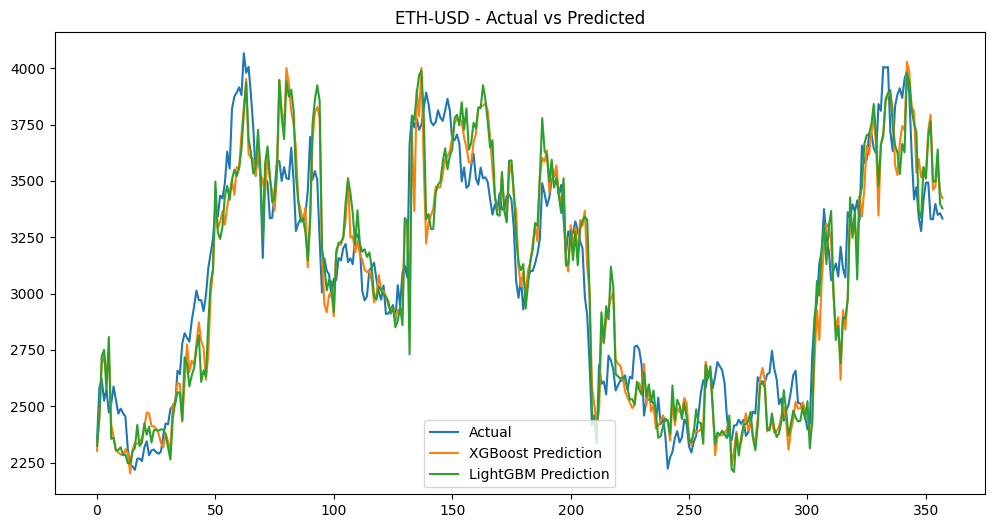

In [33]:
plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual")
plt.plot(final_xgb, label="XGBoost Prediction")
plt.plot(final_lgbm, label="LightGBM Prediction")

plt.legend()
plt.title(f"{ticker} - Actual vs Predicted")
plt.show()